In [ ]:
%%capture
!pip install torch<2.3.0 torchvision==0.17.0
!pip install tqdm
!pip install tensorflow>=1.7 opencv-contrib-python==3.3.0.9 fer
!pip install moviepy==1.0.3

In [ ]:
import os, sys
import importlib
training_scripts_path = os.getcwd()
scripts_path = os.path.dirname(training_scripts_path)
project_path = os.path.dirname(scripts_path)
sys.path.append(project_path)
data_set_path = os.path.join(project_path, 'dataset')
# print(data_set_path)

In [ ]:
#########################
#     CONFIGURACIÓN     #
#########################
# Directorios
base_dir = data_set_path
train_dir = os.path.join(base_dir, 'emociones2', 'train')
test_dir  = os.path.join(base_dir, 'emociones2', 'test')
model_dir = os.path.join(project_path, 'models')
# print(train_dir, test_dir)

In [ ]:
# Definir la carpeta para guardar logs/estadísticas
logs_dir = os.path.join(project_path, 'logs')
if not os.path.exists(logs_dir):
    os.makedirs(logs_dir)

In [ ]:
from scripts.training.transfer_learning import config_model_for_transfer_learning
from keras.src.applications.vgg16 import VGG16
import ssl
import urllib

# Disable SSL certificate verification
ssl._create_default_https_context = ssl._create_unverified_context

n_classes = 5 # angry, fearful, happy, sad, surprised

# crear modelo para transfer learning

# Local weights:
# vgg_weights = os.path.join(model_dir, 'vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5')
# model_vgg = VGG16(include_top=False, weights=vgg_weights, input_shape=(224, 224, 3))

# Remote weights:
model_vgg = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Re-enable SSL certificate verification
ssl._create_default_https_context = ssl._create_stdlib_context

t_model_vgg = config_model_for_transfer_learning(model_vgg, n_classes)

In [ ]:
from scripts.training import transfer_learning
importlib.reload(transfer_learning)
# Hiperparámetros
seed = 4578
batch_size  = 5
epochs      = 25
patience    = 10
transfer_learning_model_name = 'vgg16_tf_learning.keras'
best_model_path = os.path.join(model_dir, transfer_learning_model_name)

In [9]:
from scripts.training.transfer_learning import training_model

# Entrenar el modelo
history, best_epoch = training_model(t_model_vgg, train_dir, seed, max_epochs=epochs, batch_size=batch_size, patience=patience, path_best_model=best_model_path)

26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 431ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.1724 - val_loss: 3.5075
Epoch 13/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.1724 - val_loss: 3.5302


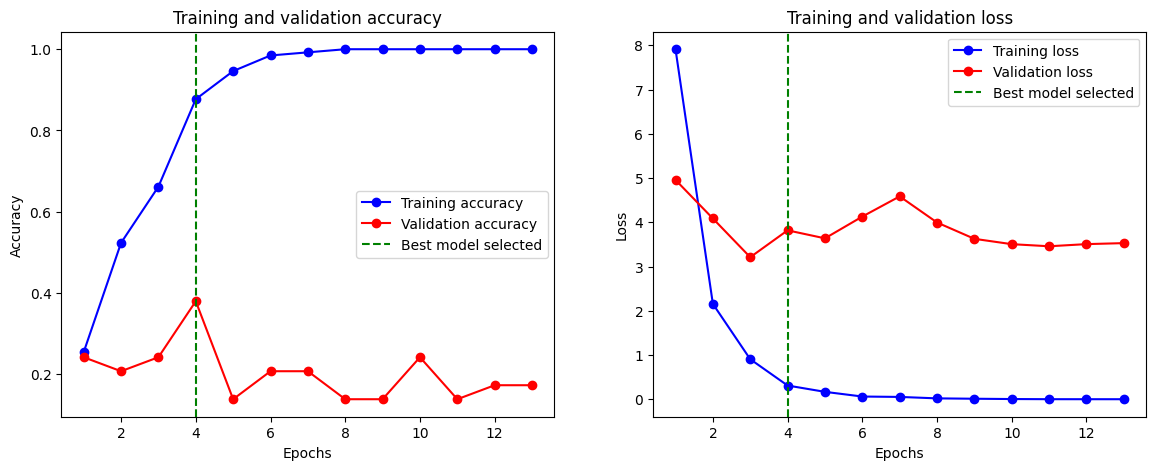

In [10]:
from scripts.training.transfer_learning import plot_learning_curves

plot_learning_curves(history, best_epoch)

Found 27 images belonging to 5 classes.
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step


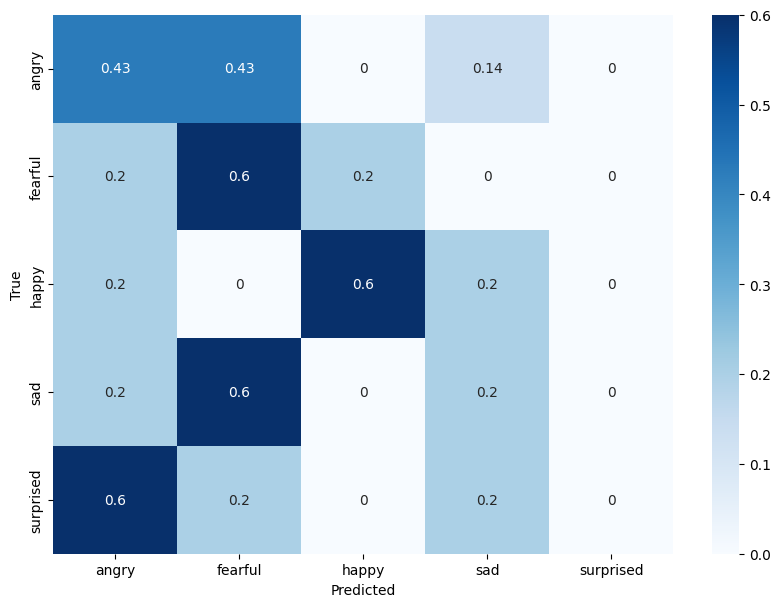

(array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,
        4, 4, 4, 4, 4], dtype=int32),
 array([0, 1, 0, 1, 0, 3, 1, 2, 1, 1, 1, 0, 2, 3, 2, 0, 2, 1, 1, 0, 3, 1,
        0, 3, 0, 0, 1]))

In [11]:
from scripts.training.transfer_learning import evaluate_model

# Evaluar el modelo usando test_dir
evaluate_model(t_model_vgg, test_dir)
